In [16]:
import glob
import fitsio
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import scienceplots
plt.style.use(['science', 'notebook', 'grid']) 
from scipy.optimize import curve_fit 
from sklearn.linear_model import LinearRegression
import os 


In [17]:
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m

In [21]:
systematics_list_debug = ['H_Alpha','Saggitarius_Density', 'Stellar_Density_AllWISE', 'CSFD', 'EBV','PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','PSFDEPTH_W1','PSFDEPTH_W2','H_Alpha_Good','PSFDEPTH_Z_RAW','PSFDEPTH_G_RAW','PSFDEPTH_R_RAW']
systematics_list = ['H_Alpha','Saggitarius_Density', 'Stellar_Density_AllWISE', 'CSFD','PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','PSFDEPTH_W1']
#systematics_list = ['H_Alpha','Saggitarius_Density', 'Stellar_Density_AllWISE', 'CSFD','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','PSFDEPTH_W1']

#systematics_list = ['CSFD']
path = 'imaging_systematics_maps/data/'
part= 'south'
mask =hp.read_map(f'{path}/{part}_mask_nside_64_for_systmatics_20M.fits')
randoms_counts = hp.read_map(f'{path}/{part}_counts_randoms_nside_64.fits')
systematics_maps = {}
for sys_name in systematics_list:
    sys_map = hp.read_map(f'{path}/{part}_{sys_name}_nside_64.fits')
    #sys_map[mask==0] = hp.UNSEEN
    #hp.mollview(sys_map, title=sys_name, unit='', cmap='YlGnBu')
    systematics_maps[sys_name] = sys_map
    data  =sys_map[mask>0]
    # plt.hist(data, bins=100, alpha=0.7)
    # plt.title(sys_name)
    # plt.xlabel('Value')
    # plt.ylabel('Counts')
    # plt.show()
data = Table(fitsio.FITS('../../table_match_final.fits')[1].read())
if part=='north':
    data = data[data['DEC']>=32.3]
elif part=='south':
    data = data[data['DEC']<32.3]
data = points_to_map(data['RA'], data['DEC'], nside=64)

remove_outliers = True

kind_no = 2
kind_dict= {1:'partial_percentile', 2:'equal'}
if remove_outliers:
    kind = kind_dict[kind_no]  # equal or partial_percentile
    val = 10
    #val = 0



no lower limit
Number of elements removed for  H_Alpha :  34655
no lower limit
Number of elements removed for  Saggitarius_Density :  34643
Number of elements removed for  Stellar_Density_AllWISE :  34776
no lower limit
Number of elements removed for  CSFD :  34522
Number of elements removed for  PSFDEPTH_Z :  35494
Number of elements removed for  PSFDEPTH_G :  35951
Number of elements removed for  PSFDEPTH_R :  36095
Number of elements removed for  PSFSIZE_G :  35736
Number of elements removed for  PSFSIZE_R :  35740
Number of elements removed for  PSFSIZE_Z :  35266
Number of elements removed for  PSFDEPTH_W1 :  35141


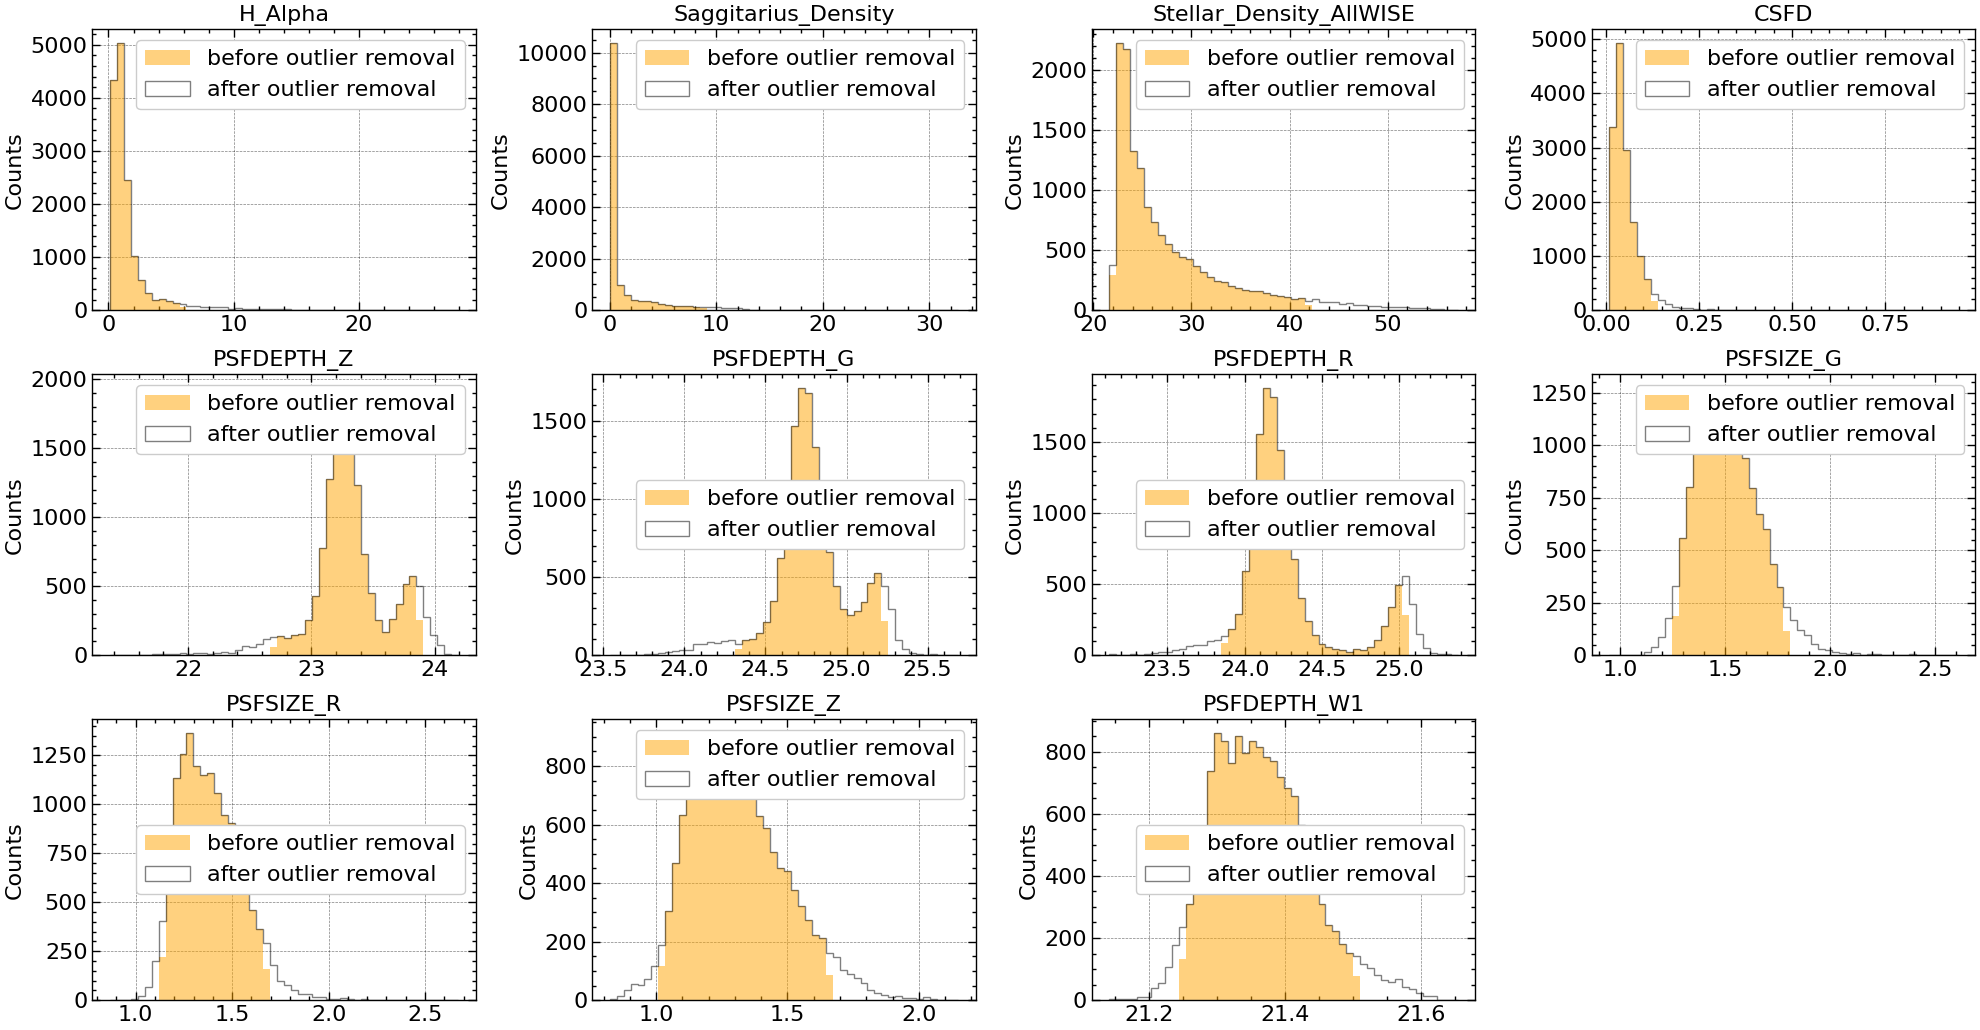

In [22]:
#removing outliers systematics
if remove_outliers:
    masks  = []
    limits = []
    
    # Calculate number of rows needed for subplots
    n_sys = len(systematics_list)
    n_cols = 4
    n_rows = (n_sys + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5*n_rows))
    axes = axes.flatten()
    
    for idx, sys_name in enumerate(systematics_list):
        sys_map = systematics_maps[sys_name]
        valid = (mask>0) & np.isfinite(sys_map)
        counts, bin_edges = np.histogram(sys_map[valid], bins=50)
        frac_area = counts/np.sum(counts)
        bin_centers = (bin_edges[:-1]+bin_edges[1:])/2
        order = np.argsort(bin_centers)
        cumfrac = np.cumsum(frac_area[order])
        cum_mask = np.zeros_like(frac_area, dtype=bool)
        cum_mask[order] = (cumfrac >=0.025) & (cumfrac <=0.975)
        if kind == 'equal':
            ul0 = (1-val/100/2)
            ll0 = (val/100/2)

            ul = np.min(bin_centers[(cumfrac >ul0)])
            try:
                ll = np.max(bin_centers[(cumfrac <ll0)])
            except:
                print('no lower limit')
                ll = np.min(sys_map[valid])
        elif kind == 'partial_percentile':
            if sys_name == 'CSFD' or sys_name == 'Saggitarius_Density' or sys_name == 'Stellar_Density_AllWISE' or sys_name == 'H_Alpha':
                ul =  np.min(bin_centers[(cumfrac >0.95)])
            else:
                ul =  np.min(bin_centers[(cumfrac >=0.99)])
            try:
                ll = np.max(bin_centers[(cumfrac <0.01)])
            except:
                print('no lower limit')
                ll = np.min(sys_map[valid])

        
        removal_mask = (sys_map >=ll) & (sys_map<=ul)
        usable_maps = sys_map[removal_mask]
        
        limits.append((ll, ul))
        print('Number of elements removed for ', sys_name, ': ', np.sum(~removal_mask ))
        
        axes[idx].hist(usable_maps, bins=bin_edges, alpha=0.5, label=f'before outlier removal', color='orange')
        axes[idx].hist(sys_map[valid], bins=bin_edges, alpha=0.5, label=f'after outlier removal', color='k', histtype='step')
        axes[idx].legend()
        axes[idx].set_title(f'{sys_name}')
        axes[idx].set_ylabel('Counts')
        
        masks.append(removal_mask)
    
    # Hide unused subplots
    for idx in range(n_sys, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    combined_masks = np.all(np.array(masks), axis=0)
else:
    combined_masks = mask>0
    kind = None
    val=None
dir_name = f'multilinear_results/{part}'
os.makedirs(dir_name, exist_ok=True)

In [77]:
# masks  = []
# limits = []
# for sys_name in systematics_list:
#     sys_map = systematics_maps[sys_name]
#     valid = (mask>0)
#     plt.hist(sys_map[combined_masks&valid], alpha=0.5, label=f'{sys_name} after outlier removal',color='k',histtype='step')
#     plt.title(f'Histogram of {sys_name} before outlier removal')
#     plt.show()

In [23]:
np.count_nonzero(combined_masks[mask==1])/len(combined_masks[mask==1])

np.float64(0.5154659486438563)

In [79]:
max_count = randoms_counts[mask==1].max()
tr = 0.0
normalized_counts = randoms_counts / max_count

randoms_counts_subtracted =np.where(normalized_counts>tr, randoms_counts, 0)

num_outside = len(normalized_counts[mask==1][normalized_counts[mask==1]<tr])
print(f'Number of pixels outside {tr}: {num_outside}, out of {len(normalized_counts[mask==1])} total pixels')

data_counts_subtracted = np.where(normalized_counts>tr, data, 0)

ngal = data_counts_subtracted[mask==1]
nran = randoms_counts_subtracted[mask==1]
pix64 = np.where(mask==1)[0]

Number of pixels outside 0.0: 0, out of 15227 total pixels


In [80]:
##removing outliers systematics
ngal = ngal[combined_masks[mask==1]]
nran = nran[combined_masks[mask==1]]
pix64 = pix64[combined_masks[mask==1]]

In [81]:
# valid = np.isfinite(ngal) & np.isfinite(nran) & (nran > 0)  & (ngal > 0)
# ngal_valid = ngal[valid]
# nran_valid = nran[valid]
# overdensity_maps  = ngal_valid/nran_valid * np.sum(nran_valid)/np.sum(ngal_valid) 

# sigma_overdensity = np.sqrt(ngal_valid)/nran_valid * np.sum(nran_valid)/np.sum(ngal_valid)

# finite_masks = {}
# sys_maps_for_fit = {}
# for sys_interated in systematics_list:
#     temp  = hp.read_map(f'{path}/{part}_{sys_interated}_nside_64.fits')


#     sys_maps_for_fit[sys_interated] = temp[mask==1][combined_masks[mask==1]][valid]
#     finite_mask  = np.isfinite(temp[mask==1][combined_masks[mask==1]][valid])
#     finite_masks[sys_interated] = finite_mask
#     num_nan = np.sum(~finite_mask)
#     if num_nan > 0:
#         print(f'Systematic {sys_interated}: {num_nan} NaN values within the mask')
    

# finite_mask_combined = np.all([finite_masks[sys] for sys in systematics_list],axis=0)
# sys_map_for_fit_combined = np.vstack([sys_maps_for_fit[sys]-np.nanmean(sys_maps_for_fit[sys]) for sys in systematics_list]).T

# tot_map = np.full(hp.nside2npix(64), np.nan)


# model = LinearRegression(fit_intercept=False)

# w = 1/ sigma_overdensity**2
# #model.fit(sys_map_for_fit_combined[finite_mask_combined], overdensity_maps[finite_mask_combined], sample_weight=w[finite_mask_combined])


# overdensity_full = np.full(len(ngal), np.nan)



# overdensity_full[valid] = overdensity_maps
# sigma_overdensity_full = np.full(len(ngal), np.nan)
# sigma_overdensity_full[valid] = sigma_overdensity
# tot_map[combined_masks] = overdensity_full
# #tot_map[combined_masks] = sigma_overdensity_full

# #hp.mollview(tot_map, title=f'{part.upper()} Overdensity Map nside=64', unit='Overdensity', cmap='coolwarm',min = 0, max = np.percentile(sigma_overdensity_full[np.isfinite(sigma_overdensity_full)],99))

Multilinear Regression Coefficients with Uncertainties:
H_Alpha                       : -0.044035 ± 0.001861
Saggitarius_Density           : -0.000416 ± 0.000938
Stellar_Density_AllWISE       : -0.007102 ± 0.000463
CSFD                          : -1.215653 ± 0.082199
PSFDEPTH_Z                    : 0.352261 ± 0.013547
PSFDEPTH_G                    : 0.344010 ± 0.015630
PSFDEPTH_R                    : -0.492371 ± 0.011027
PSFSIZE_G                     : -0.099067 ± 0.013750
PSFSIZE_R                     : -0.113505 ± 0.014264
PSFSIZE_Z                     : -0.011474 ± 0.012180
PSFDEPTH_W1                   : 0.551870 ± 0.024938


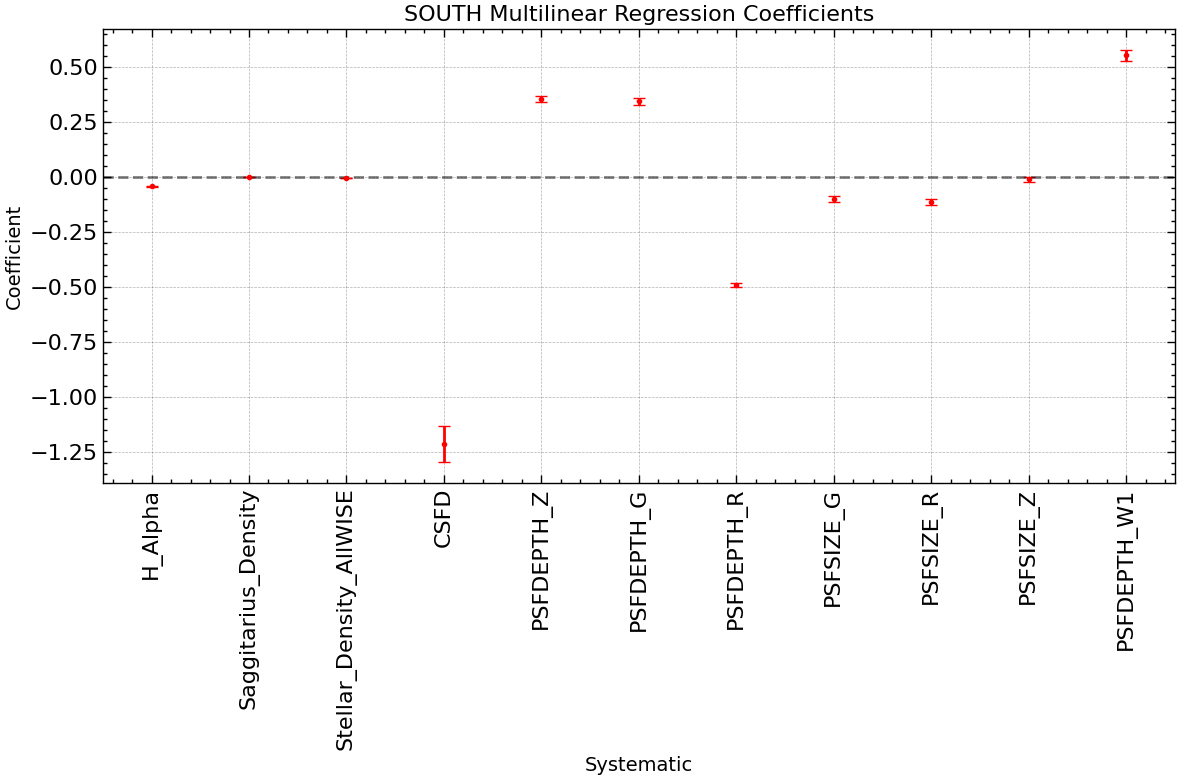

In [82]:
# Calculate coefficient uncertainties from weighted least squares
# Using the covariance matrix approach

valid = np.isfinite(ngal) & np.isfinite(nran) & (nran > 0) & (ngal > 0)
ngal_valid = ngal[valid]
nran_valid = nran[valid]

# Compute overdensity
#overdensity_maps = ngal_valid / nran_valid * np.sum(nran_valid) / np.sum(ngal_valid)

# Prepare feature matrix (centered)
sys_maps_for_fit = {}
for sys_name in systematics_list:
    temp = hp.read_map(f'{path}/{part}_{sys_name}_nside_64.fits')
    sys_maps_for_fit[sys_name] = temp[mask==1][combined_masks[mask==1]][valid]

finite_mask_combined = np.all([np.isfinite(sys_maps_for_fit[sys]) for sys in systematics_list], axis=0)
ngal_valid = ngal_valid[finite_mask_combined]
nran_valid = nran_valid[finite_mask_combined]
overdensity_maps = ngal_valid / nran_valid * np.sum(nran_valid) / np.sum(ngal_valid)

X = np.vstack([sys_maps_for_fit[sys][finite_mask_combined] - np.nanmean(sys_maps_for_fit[sys][finite_mask_combined]) 
               for sys in systematics_list]).T

y = overdensity_maps-1 

# Weights (inverse variance)
sigma_y = np.sqrt(ngal_valid) / nran_valid * np.sum(nran_valid) / np.sum(ngal_valid)
W = np.diag(1.0 / sigma_y**2)

# Weighted least squares: beta = (X^T W X)^-1 X^T W y
XtWX = X.T @ W @ X
XtWy = X.T @ W @ y

# Coefficients
coeffs = np.linalg.solve(XtWX, XtWy)

# Covariance matrix of coefficients
cov_matrix = np.linalg.inv(XtWX)

# Standard errors (uncertainties)
coeff_errors = np.sqrt(np.diag(cov_matrix))


print("Multilinear Regression Coefficients with Uncertainties:")
print("=" * 60)
for i, sys_name in enumerate(systematics_list):
    print(f"{sys_name:30s}: {coeffs[i]:8.6f} ± {coeff_errors[i]:.6f}")


plt.figure(figsize=(12, 8))
plt.errorbar(range(len(systematics_list)), coeffs, yerr=coeff_errors, 
             fmt='o', capsize=4, markersize=3, linewidth=2,color='r')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xticks(range(len(systematics_list)), systematics_list, rotation=90)
plt.ylabel('Coefficient', fontsize=14)
plt.xlabel('Systematic', fontsize=14)
plt.title(f'{part.upper()} Multilinear Regression Coefficients', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [83]:

f'{dir_name}'

'multilinear_results/south'

In [84]:
if kind == 'equal':
    np.save(f'{dir_name}/{part}_multilinear_regression_coefficients_{kind}_{val}.npy', {'coefficients': coeffs, 'errors': coeff_errors, 'systematics': systematics_list})
elif kind == 'partial_percentile':
    np.save(f'{dir_name}/{part}_multilinear_regression_coefficients_{kind}.npy', {'coefficients': coeffs, 'errors': coeff_errors, 'systematics': systematics_list})
else:
    np.save(f'{dir_name}/{part}_multilinear_regression_coefficients_full_sample.npy', {'coefficients': coeffs, 'errors': coeff_errors, 'systematics': systematics_list})

In [85]:
# coeffs_north_partial_percentile = coeffs
# coeffs_error_north_partial_percentile=coeff_errors
# coeffs_south_partial_percentile = coeffs
# coeffs_error_south_partial_percentile=coeff_errors
# coeffs_full_partial_percentile = coeffs
# coeffs_error_full_partial_percentile=coeff_errors
# for part in ['north', 'south', 'full']:
#     np.savetxt(f'coeffs_{part}_partial_percentile.txt', coeffs)
#     np.savetxt(f'coeffs_error_{part}_partial_percentile.txt', coeff_errors)

# plt.figure(figsize=(12, 8))
# plt.errorbar(range(len(systematics_list)), coeffs_north_partial_percentile, yerr=coeffs_error_north_partial_percentile, 
#              fmt='o', capsize=4, markersize=3, linewidth=2,color='r',label='North')
# plt.errorbar(range(len(systematics_list)), coeffs_south_partial_percentile, yerr=coeffs_error_south_partial_percentile, 
#              fmt='o', capsize=4, markersize=3, linewidth=2,color='b',label='South')

# plt.errorbar(range(len(systematics_list)), coeffs_full_partial_percentile, yerr=coeffs_error_full_partial_percentile, 
#              fmt='o', capsize=4, markersize=3, linewidth=2,color='g',label='Full')
# plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
# plt.xticks(range(len(systematics_list)), systematics_list, rotation=90)
# plt.ylabel('Coefficient', fontsize=14)
# plt.xlabel('Systematic', fontsize=14)
# plt.title(f'Multilinear Regression Coefficients with ', fontsize=16)
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

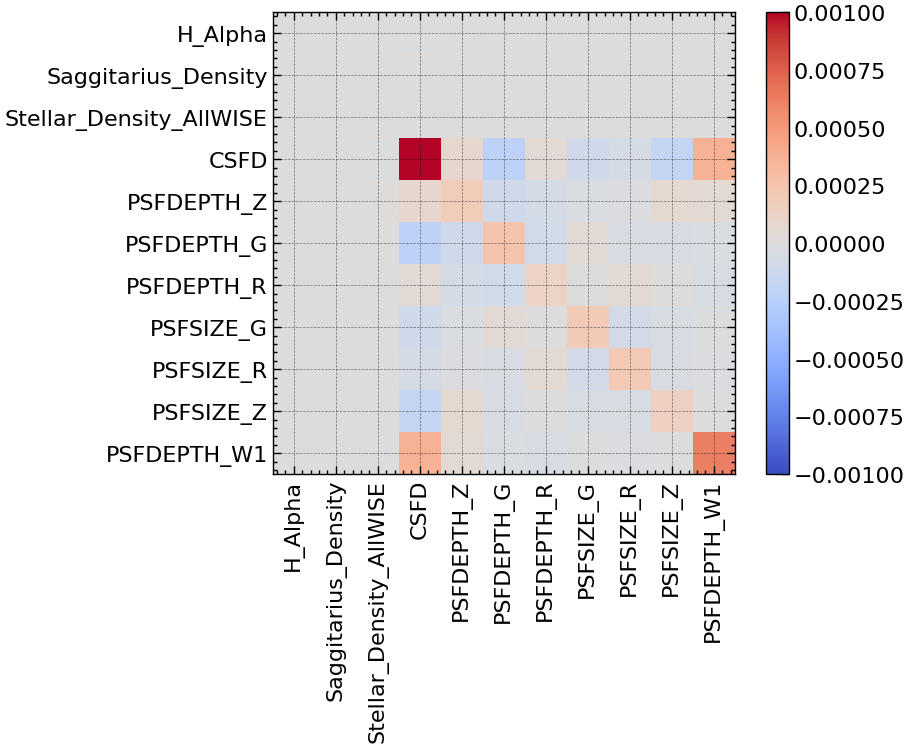

In [86]:
plt.imshow(cov_matrix, cmap='coolwarm',vmin = -0.001,vmax = 0.001)
plt.xticks(range(len(systematics_list)), systematics_list, rotation=90)
plt.yticks(range(len(systematics_list)), systematics_list)
plt.colorbar()

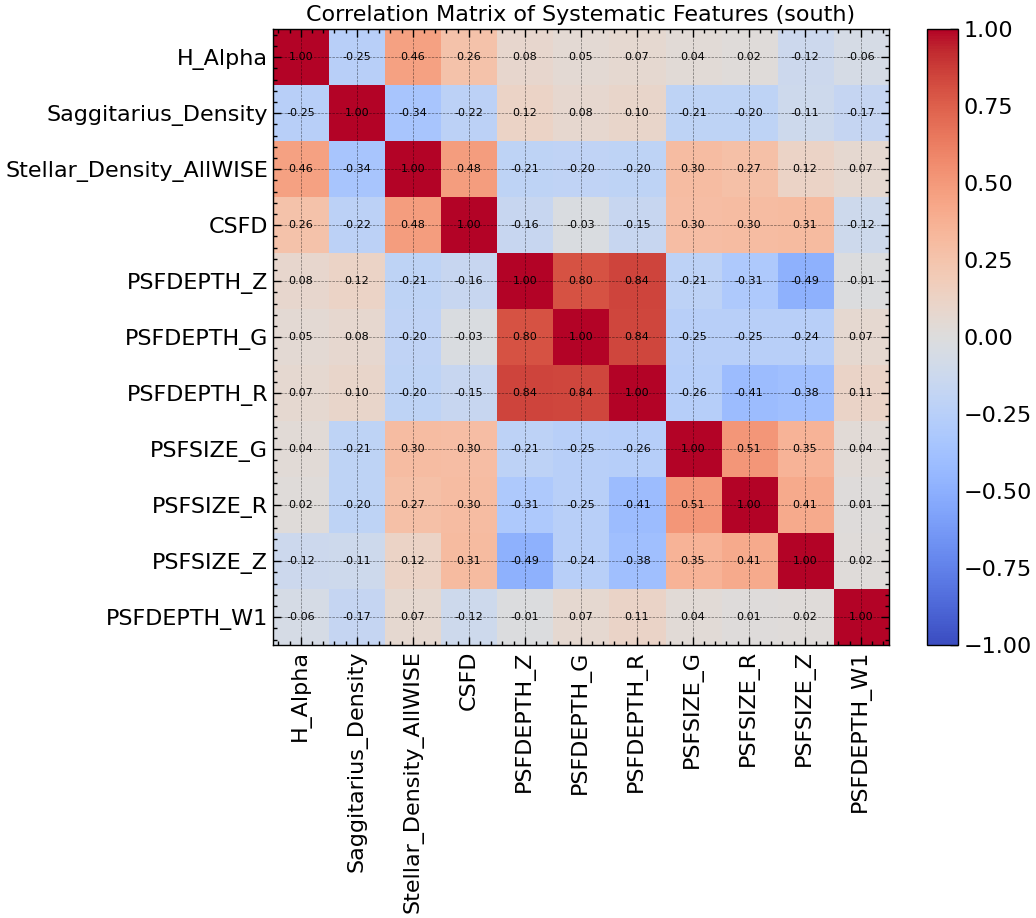

In [87]:
corr = np.corrcoef(X, rowvar=False)
plt.figure(figsize=(10, 8))
im = plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.xticks(range(len(systematics_list)), systematics_list, rotation=90)
plt.yticks(range(len(systematics_list)), systematics_list)
plt.title(f'Correlation Matrix of Systematic Features ({part})', fontsize=16)

# Add text annotations showing correlation values
for i in range(len(systematics_list)):
    for j in range(len(systematics_list)):
        text = plt.text(j, i, f'{corr[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)
plt.colorbar()

In [88]:
pred_overdens = X@coeffs
pred_map = np.full(hp.nside2npix(64), 1)
pix_all = np.where(mask == 1)[0]          # pixels in footprint
pix_valid = pix_all[combined_masks[mask==1]][valid]               # valid ngal/nran pixels
pix_fit = pix_valid[finite_mask_combined] # pixels used in regression
    
pred_map[pix_fit] = pred_overdens
weights = 1 / (1+pred_overdens)
weights = np.clip(weights, 0.5, 2.0)
weights = weights/np.mean(weights)

In [89]:
pred_overdens = coeffs@X.T
pred_map = np.full(hp.nside2npix(64), np.nan)
pix_all = np.where(mask == 1)[0]          # pixels in footprint
pix_valid = pix_all[combined_masks[mask==1]][valid]               # valid ngal/nran pixels
pix_fit = pix_valid[finite_mask_combined] # pixels used in regression

pred_map[pix_fit] = pred_overdens

og_map = np.full(hp.nside2npix(64), np.nan)
og_map[pix_fit] = y

(array([7.740e+03, 3.104e+03, 3.730e+02, 8.600e+01, 2.200e+01, 1.000e+01,
        5.000e+00, 0.000e+00, 1.000e+00, 1.000e+00]),
 array([  1. ,  26.7,  52.4,  78.1, 103.8, 129.5, 155.2, 180.9, 206.6,
        232.3, 258. ]),
 <BarContainer object of 10 artists>)

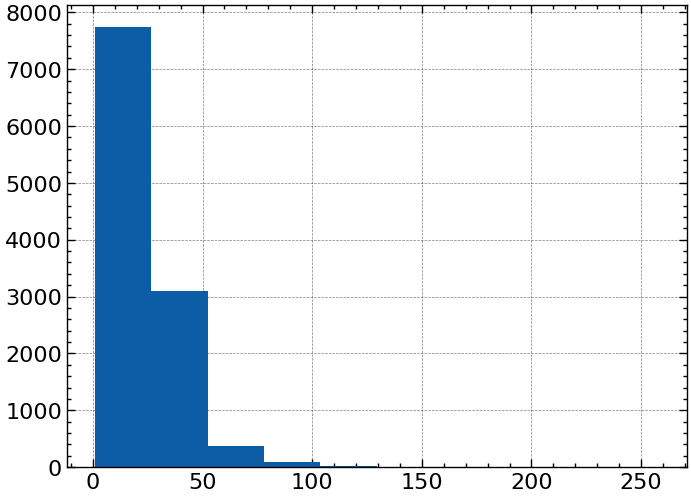

In [90]:
plt.hist(ngal_valid)

In [91]:
ngal_corr_valid = weights * ngal_valid


In [92]:
valid

array([False, False, False, ...,  True,  True,  True], shape=(11446,))

In [93]:
combined_masks[mask==1]

array([False, False, False, ..., False, False, False], shape=(15227,))

In [94]:
pix64

array([10369, 10370, 10610, ..., 36797, 36798, 36854], shape=(11446,))

In [95]:
nside = 6
pix64_plotting = pix64[valid]
theta, phi = hp.pix2ang(64, pix64_plotting, nest=False)
jk_pix_full = hp.ang2pix(nside, theta, phi, nest=False)
_, jk_labels_full = np.unique(jk_pix_full, return_inverse=True)
jk_labels_full = jk_labels_full[finite_mask_combined]

In [96]:
len(ngal_valid), len(nran_valid), len(data)

(11342, 11342, 49152)

In [97]:
from delta_sys import error_jackknife_patch, finalize_data


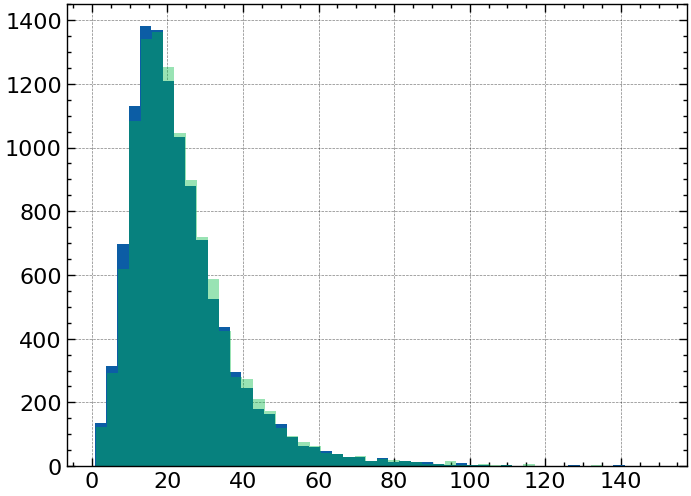

In [98]:
plt.hist(ngal_corr_valid,bins = 50 , range=(ngal_corr_valid.min(), 150))
plt.hist(ngal_valid,bins = 50 , range=(ngal_valid.min(), 150),alpha=0.4)
plt.show()

lentgh of ngal: 11342, nran: 11342, features: 11342, n_jack: 160, full_vals length: 40, length of mask: 11342
lentgh of ngal: 11342, nran: 11342, features: 11342, n_jack: 160, full_vals length: 40, length of mask: 11342
lentgh of ngal: 11342, nran: 11342, features: 11342, n_jack: 160, full_vals length: 40, length of mask: 11342
lentgh of ngal: 11342, nran: 11342, features: 11342, n_jack: 160, full_vals length: 40, length of mask: 11342
lentgh of ngal: 11342, nran: 11342, features: 11342, n_jack: 160, full_vals length: 40, length of mask: 11342
lentgh of ngal: 11342, nran: 11342, features: 11342, n_jack: 160, full_vals length: 40, length of mask: 11342
lentgh of ngal: 11342, nran: 11342, features: 11342, n_jack: 160, full_vals length: 40, length of mask: 11342
lentgh of ngal: 11342, nran: 11342, features: 11342, n_jack: 160, full_vals length: 40, length of mask: 11342
lentgh of ngal: 11342, nran: 11342, features: 11342, n_jack: 160, full_vals length: 40, length of mask: 11342
lentgh of 

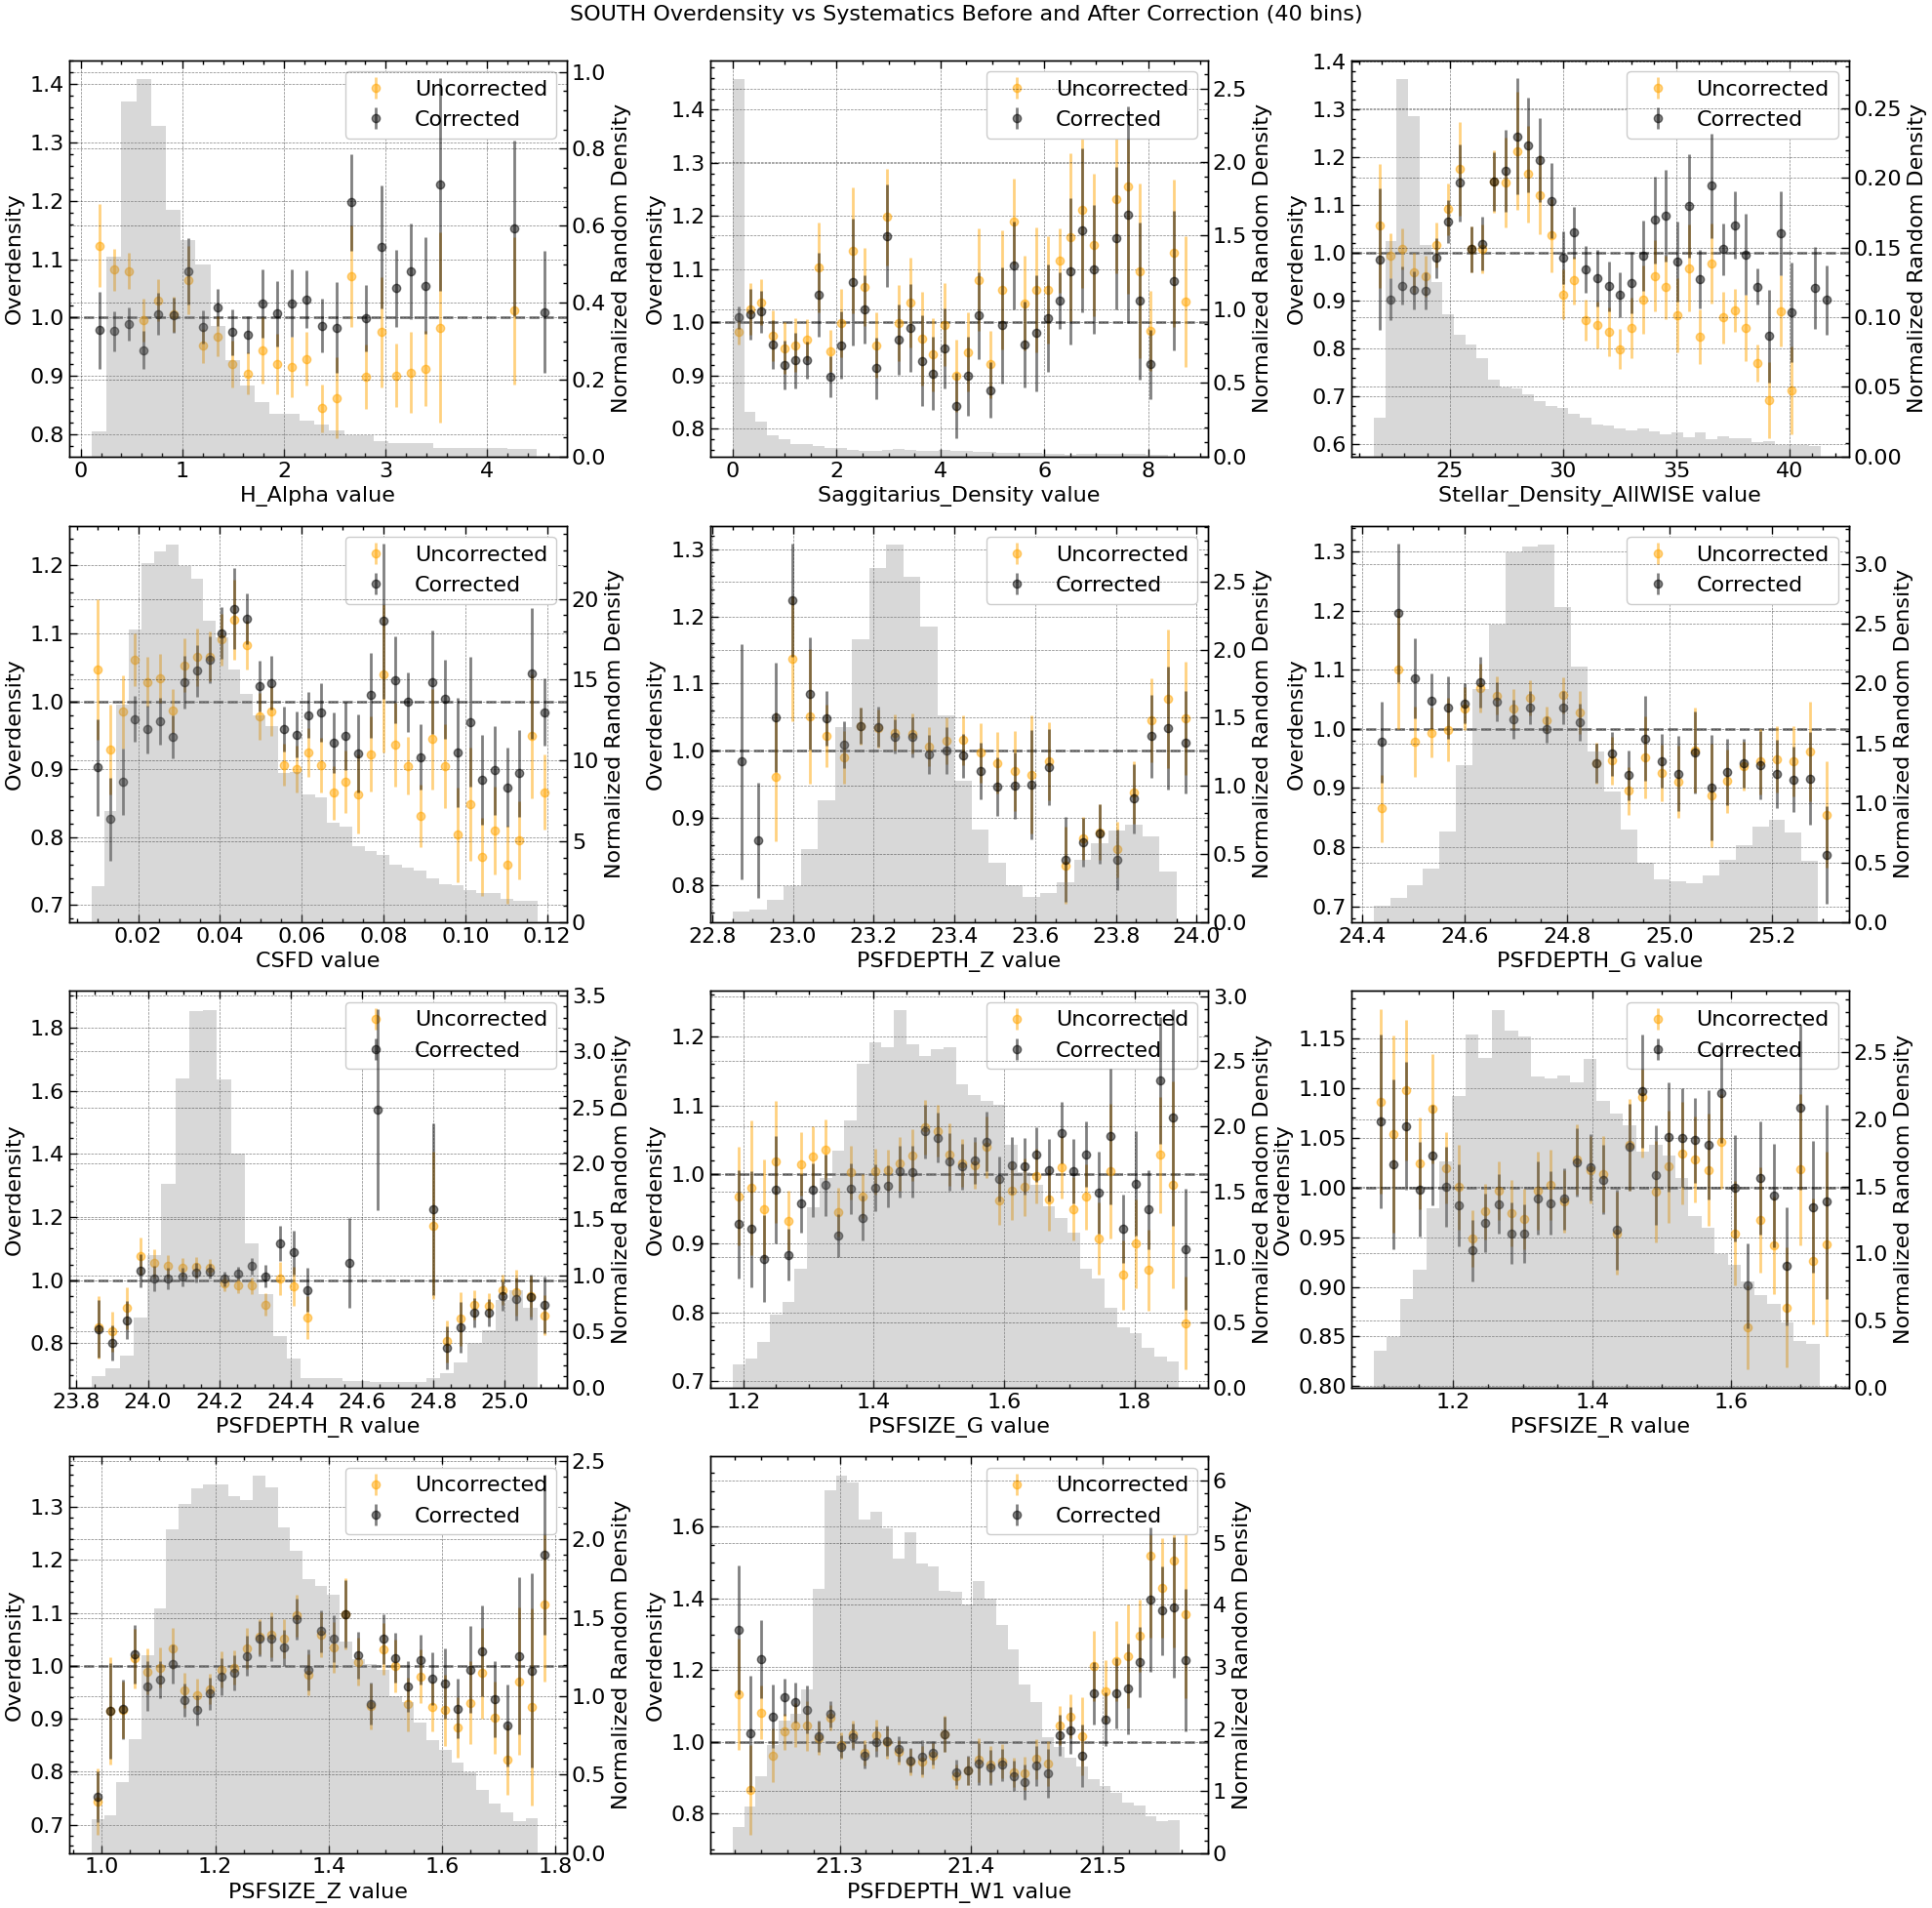

In [99]:
binning  ='linear'
nbins = 40

n_sys = len(systematics_list)
n_cols = 3
n_rows = (n_sys + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for sys_ix, sys_map_plot in enumerate(systematics_list):
    ax1 = axes[sys_ix]
    data  = sys_maps_for_fit[sys_map_plot][finite_mask_combined]
    counts, bin_edges = np.histogram(data, bins=100,weights = nran_valid)
    frac_area = counts/np.sum(counts)
    bin_centers = (bin_edges[:-1]+bin_edges[1:])/2
    order = np.argsort(bin_centers)
    cumfrac = np.cumsum(frac_area[order])
    num_mask = np.zeros_like(frac_area, dtype=bool)

    num_mask[order] = (cumfrac >= 0.05) & (cumfrac <= 0.95)
    x_lo = bin_edges[:-1][num_mask].min()
    x_hi = bin_edges[1:][num_mask].max()
    percentile_masking   = (data >= x_lo) & (data <= x_hi)
    
    bin_centers, full_vals, jk_err, data_full, rands_full, n_jack,bin_edges = error_jackknife_patch(
            ngal_valid, nran_valid, data,num_bins =nbins, nside=nside, ax=None,binning=binning,jk_labels=jk_labels_full
        )

    usable, bad_reasons = finalize_data(
                full_vals=full_vals,
                jk_err=jk_err,
                data_full=data_full,
                rands_full=rands_full,n_jack=n_jack)
    ax1.errorbar(bin_centers[usable], full_vals[usable], yerr=jk_err[usable], fmt='o', label=f'Uncorrected', zorder=5,alpha=0.5,color='orange')
    
    bin_centers, full_vals_corr, jk_err_corr, data_full_corr, rands_full, n_jack,bin_edges = error_jackknife_patch(
            ngal_corr_valid, nran_valid, data,num_bins =nbins, nside=nside, ax=None,binning=binning,jk_labels=jk_labels_full
        )

    usable, bad_reasons = finalize_data(
                full_vals=full_vals_corr,
                jk_err=jk_err_corr,
                data_full=data_full_corr,
                rands_full=rands_full,n_jack=n_jack)
    ax1.errorbar(bin_centers[usable], full_vals_corr[usable], yerr=jk_err_corr[usable], fmt='o', label=f'Corrected', zorder=10,alpha=0.5,color='k')
    ax1.axhline(y=1, color='k', linestyle='--', alpha=0.5)
    
    ax1.legend()
    ax2 = ax1.twinx()
    ax2.hist(data, bins=bin_edges[:-1][usable], weights=nran_valid, color='gray', alpha=0.3, label='Random-weighted footprint', density=True, zorder=0)
    ax2.set_ylabel('Normalized Random Density')
    ax1.set_xlabel(f'{sys_map_plot} value')
    ax1.set_ylabel('Overdensity')
    #ax1.set_title(f'{sys_map_plot}')

# Hide unused subplots
for idx in range(n_sys, len(axes)):
    axes[idx].axis('off')
# Hide unused subplots
for idx in range(n_sys, len(axes)):
    axes[idx].axis('off')

fig.suptitle(f'{part.upper()} Overdensity vs Systematics Before and After Correction ({nbins} bins)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
if remove_outliers:
    if val is not None:
        plt.savefig(f'{dir_name}/{part}_multilinear_overdensity_systematics_before_after_correction_{kind}_{val}.png', dpi=300)
    else:
        plt.savefig(f'{dir_name}/{part}_multilinear_overdensity_systematics_before_after_correction_{kind}.png', dpi=300)
else:
    plt.savefig(f'{dir_name}/{part}_multilinear_overdensity_systematics_before_after_correction_full_sample.png', dpi=300)
plt.show()



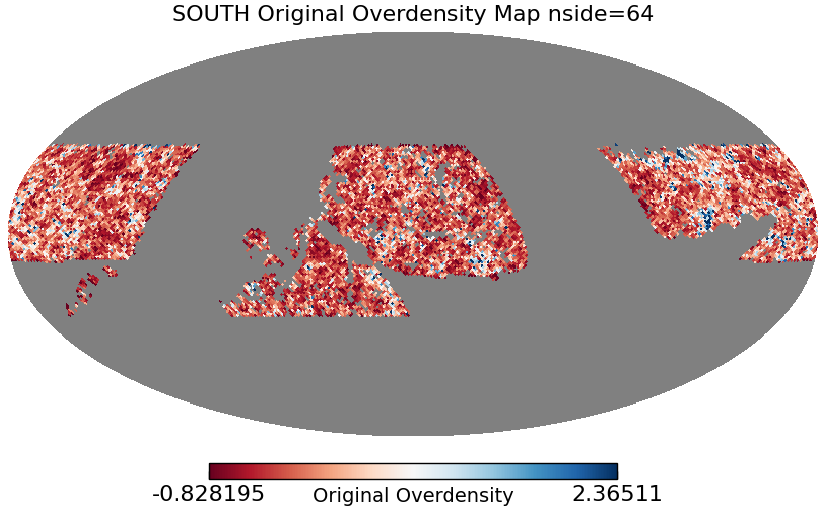

In [100]:
hp.mollview(og_map, title=f'{part.upper()} Original Overdensity Map nside=64', unit='Original Overdensity', cmap='RdBu', min = np.percentile(y,1), max = np.percentile(y,99))

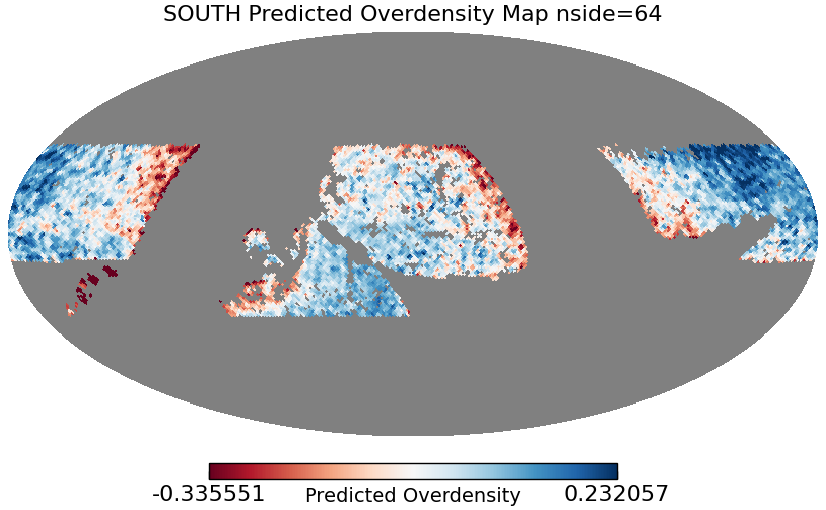

In [101]:
hp.mollview(pred_map, title=f'{part.upper()} Predicted Overdensity Map nside=64', unit='Predicted Overdensity', cmap='RdBu', min = np.percentile(pred_overdens,1), max = np.percentile(pred_overdens,99))
if kind == 'equal':
    plt.savefig(f'{dir_name}/{part}_predicted_overdensity_map_{kind}_{val}.png', dpi=300)
elif kind == 'partial_percentile':  
    plt.savefig(f'{dir_name}/{part}_predicted_overdensity_map_{kind}.png', dpi=300)
else: 
    plt.savefig(f'{dir_name}/{part}_predicted_overdensity_map_full_sample.png', dpi=300)

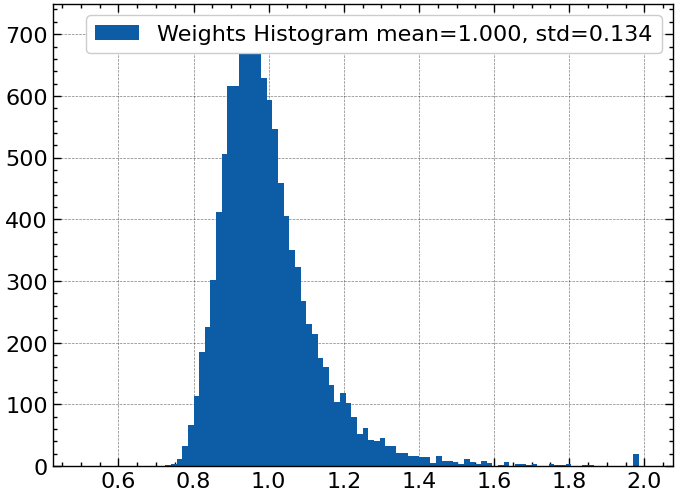

In [102]:
plt.hist(weights,range=(0.5,2), bins=100,label=f'Weights Histogram mean={np.mean(weights):.3f}, std={np.std(weights):.3f}')
plt.legend()
plt.savefig(f'{dir_name}/{part}_weights_histogram_{kind}_{val}.png', dpi=300)
plt.show()

In [103]:
npix = hp.nside2npix(64)

pix_all = np.arange(npix)
pix_fit = pix_all[mask==1][combined_masks[mask==1]][valid][finite_mask_combined]

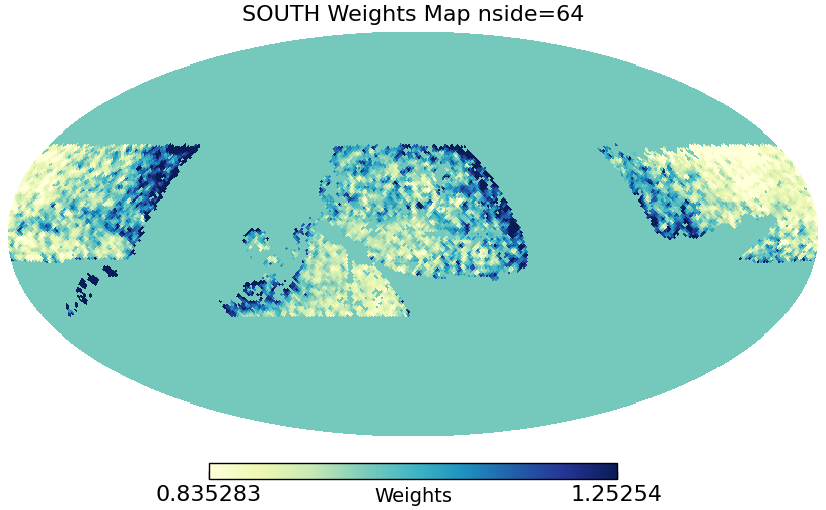

In [104]:
wgt_map = np.ones(npix, dtype=float)
wgt_map[pix_fit] = weights
#hp.mollview(wgt_map, title=f'{part.upper()} Weights Map nside=64',cmap='YlGnBu', unit='Weights',)
hp.mollview(wgt_map, title=f'{part.upper()} Weights Map nside=64',cmap='YlGnBu', unit='Weights', min = np.nanpercentile(wgt_map, 1), max = np.nanpercentile(wgt_map, 99),)

In [105]:
if kind == 'equal':
    hp.write_map(f'{dir_name}/{part}_multilinear_systematic_weights_nside64_{kind}_{val}.fits', wgt_map,overwrite=True)
elif kind == 'partial_percentile':
    hp.write_map(f'{dir_name}/{part}_multilinear_systematic_weights_nside64_{kind}.fits', wgt_map,overwrite=True)
else:    
    hp.write_map(f'{dir_name}/{part}_multilinear_systematic_weights_nside64_full_sample.fits', wgt_map,overwrite=True)

setting the output map dtype to [dtype('float64')]


In [106]:
# plt.figure(figsize=(10, 6))

# # Plot single point with error bar for outlier removed
# plt.errorbar(0.5,-4.581002, yerr=0.073759, fmt='o', color='orange', markersize=10, capsize=8, linewidth=2, label='With outlier removed at 90%')
# plt.errorbar(0.5, -3.784626, yerr=0.054305, fmt='o', color='blue', 
#              markersize=10, capsize=8, linewidth=2, label='With outlier removed at 95%')

# # Plot single point with error bar for full sample

# plt.errorbar(0.5,-3.575405, yerr=0.050154, fmt='o', color='green', markersize=10, capsize=8, linewidth=2, label='Outlier removed at 97.5%')
# plt.errorbar(0.5,  -2.570621, yerr=0.039467, fmt='o', color='red', 
#              markersize=10, capsize=8, linewidth=2, label='Full sample')
# plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
# plt.ylabel('Coefficient', fontsize=14)
# plt.title('Comparison of CSFD Coefficients South', fontsize=16)
# plt.legend(fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.xlim(0, 1)
# #plt.xticks([0.3, 0.7], ['With outlier removed', 'Full sample'], rotation=15)
# plt.tight_layout()
# plt.show()

In [107]:
# plt.figure(figsize=(10, 6))

# # Plot single point with error bar for outlier removed
# plt.errorbar(0.5,4.287747, yerr=0.130490, fmt='o', color='orange', markersize=10, capsize=8, linewidth=2, label='With outlier removed at 90%')
# plt.errorbar(0.5, 2.246470, yerr=0.097064, fmt='o', color='blue', 
#              markersize=10, capsize=8, linewidth=2, label='With outlier removed at 95%')

# # Plot single point with error bar for full sample

# plt.errorbar(0.5, 0.683735, yerr=0.074361, fmt='o', color='green', markersize=10, capsize=8, linewidth=2, label='Outlier removed at 97.5%')
# plt.errorbar(0.5, -0.489374, yerr=0.060304, fmt='o', color='red', 
#              markersize=10, capsize=8, linewidth=2, label='Full sample')
# plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
# plt.ylabel('Coefficient', fontsize=14)
# plt.title('Comparison of CSFD Coefficients North', fontsize=16)
# plt.legend(fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.xlim(0, 1)
# #plt.xticks([0.3, 0.7], ['With outlier removed', 'Full sample'], rotation=15)
# plt.tight_layout()
# plt.show()

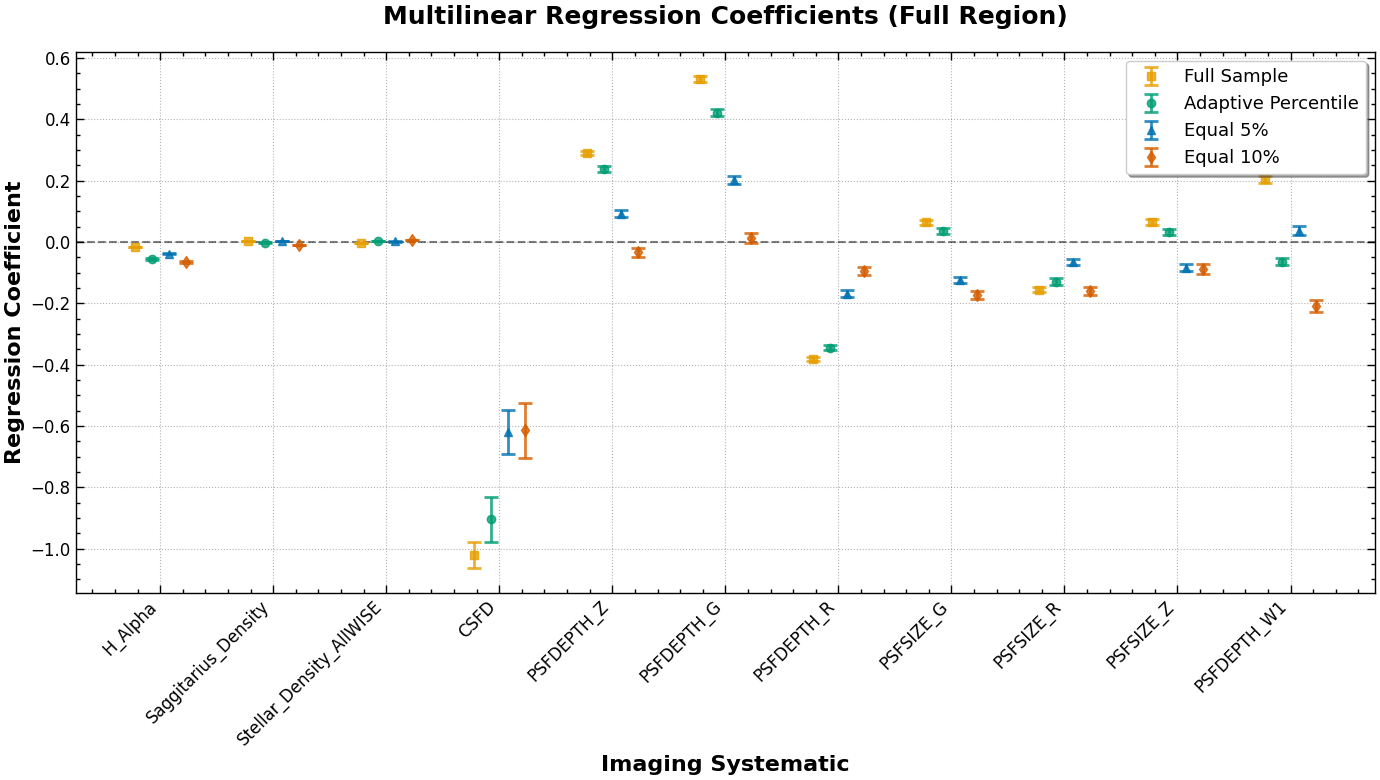

In [112]:
part = 'full'
dir_name = f'multilinear_results/{part}'
partial_percentile = f'{dir_name}/{part}_multilinear_regression_coefficients_partial_percentile.npy'
equal_5 = f'{dir_name}/{part}_multilinear_regression_coefficients_equal_5.npy'
equal_10 = f'{dir_name}/{part}_multilinear_regression_coefficients_equal_10.npy'
full_sample = f'{dir_name}/{part}_multilinear_regression_coefficients_full_sample.npy'

# Load data
data_full = np.load(full_sample, allow_pickle=True).item()
data_partial = np.load(partial_percentile, allow_pickle=True).item()
data_equal5 = np.load(equal_5, allow_pickle=True).item()
data_equal10 = np.load(equal_10, allow_pickle=True).item()

# Create publication-ready figure
fig, ax = plt.subplots(figsize=(14, 8))

x_pos = np.arange(len(systematics_list))
offset = 0.15

# Plot with distinct markers and colors
ax.errorbar(x_pos - 1.5*offset, data_full['coefficients'], yerr=data_full['errors'], 
            fmt='s', capsize=5, markersize=6, linewidth=2, color='#E69F00', 
            label='Full Sample', alpha=0.8, capthick=2)
ax.errorbar(x_pos - 0.5*offset, data_partial['coefficients'], yerr=data_partial['errors'], 
            fmt='o', capsize=5, markersize=6, linewidth=2, color='#009E73', 
            label='Adaptive Percentile', alpha=0.8, capthick=2)
ax.errorbar(x_pos + 0.5*offset, data_equal5['coefficients'], yerr=data_equal5['errors'], 
            fmt='^', capsize=5, markersize=6, linewidth=2, color='#0072B2', 
            label='Equal 5%', alpha=0.8, capthick=2)
ax.errorbar(x_pos + 1.5*offset, data_equal10['coefficients'], yerr=data_equal10['errors'], 
            fmt='d', capsize=5, markersize=6, linewidth=2, color='#D55E00', 
            label='Equal 10%', alpha=0.8, capthick=2)

# Styling
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5, zorder=0)
ax.set_xticks(x_pos)
ax.set_xticklabels(systematics_list, rotation=45, ha='right', fontsize=13)
ax.set_ylabel('Regression Coefficient', fontsize=16, fontweight='bold')
ax.set_xlabel('Imaging Systematic', fontsize=16, fontweight='bold')
ax.set_title(f'Multilinear Regression Coefficients ({part.capitalize()} Region)', 
             fontsize=18, fontweight='bold', pad=20)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=13, frameon=True, fancybox=True, shadow=True, loc='best')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)

plt.tight_layout()
#plt.savefig(f'{dir_name}/{part}_coefficients_comparison_publication.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{dir_name}/{part}_coefficients_comparison_publication.png', dpi=300, bbox_inches='tight')
plt.show()
